In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import os
import re
print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
plt.style.use('seaborn-v0_8-darkgrid')

# Load the dataset - with low_memory=False to fix the warning
df = pd.read_csv('../data/raw/cfpb_complaints.csv', low_memory=False)

# Basic information
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

DATASET OVERVIEW
Shape: (9609797, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']

First 3 rows:
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of your report   

                                       Sub-issue Consumer

PRODUCT DISTRIBUTION

All unique products in dataset:
<ArrowStringArray>
[                         'Credit reporting or other personal consumer reports',
                                                              'Debt collection',
                                                                  'Credit card',
                                                  'Checking or savings account',
                           'Money transfer, virtual currency, or money service',
                                                        'Vehicle loan or lease',
                                                    'Debt or credit management',
                                                                     'Mortgage',
                      'Payday loan, title loan, personal loan, or advance loan',
                                                                 'Prepaid card',
                                                                 'Student loan',
                                    

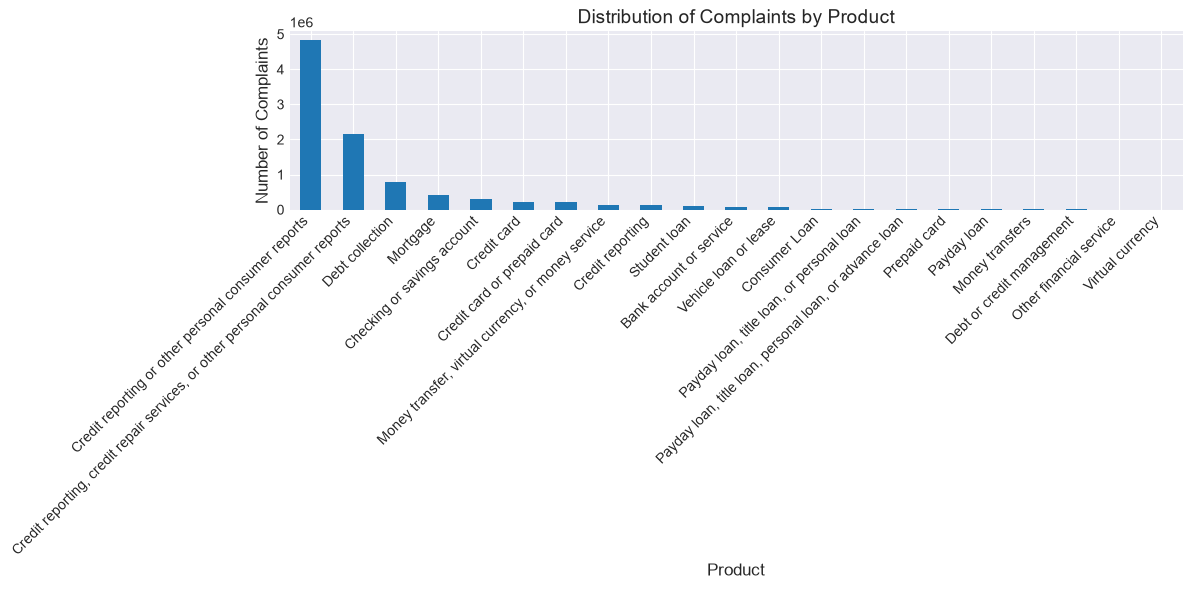

In [9]:
print("=" * 50)
print("PRODUCT DISTRIBUTION")
print("=" * 50)

# See all unique products
print("\nAll unique products in dataset:")
print(df['Product'].unique())

# Count complaints by product
product_counts = df['Product'].value_counts()
print("\nProduct counts:")
print(product_counts)

# Plot product distribution
plt.figure(figsize=(12, 6))
product_counts.plot(kind='bar')
plt.title('Distribution of Complaints by Product', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

FILTERING TO TARGET PRODUCTS
Original dataset size: 9,609,797
After filtering to 4 products: 921,808

Products in filtered dataset:
Product_standardized
Credit card        433055
Savings account    291178
Money transfer     150420
Personal loan       47155
Name: count, dtype: int64


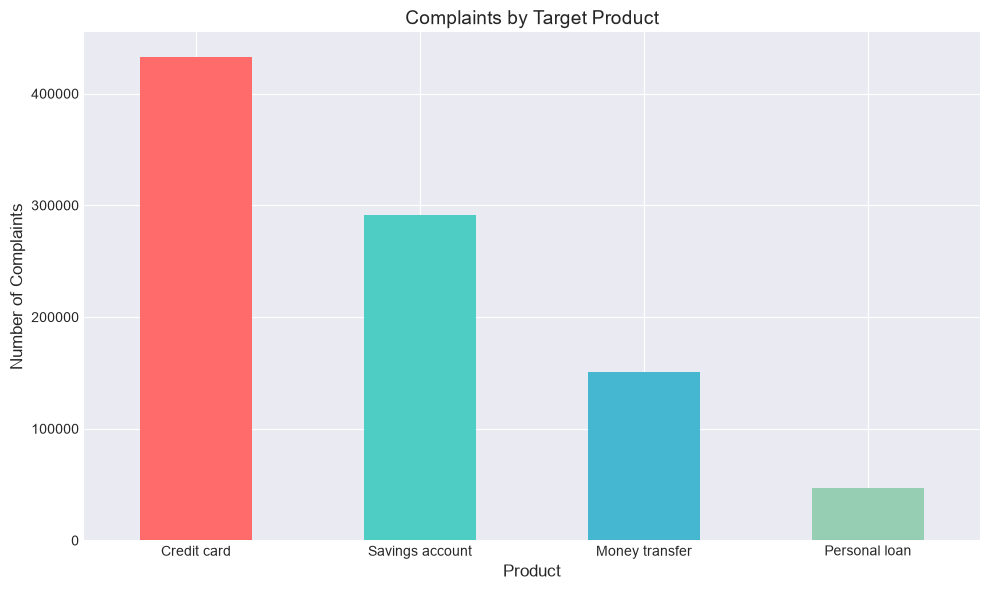

In [10]:
print("=" * 50)
print("FILTERING TO TARGET PRODUCTS")
print("=" * 50)

# Define function to standardize product names
def standardize_product(product_name):
    """Map product variations to standard names"""
    if pd.isna(product_name):
        return None
    product_name_lower = str(product_name).lower()
    
    if 'credit card' in product_name_lower:
        return 'Credit card'
    elif 'personal loan' in product_name_lower:
        return 'Personal loan'
    elif 'savings account' in product_name_lower or 'saving account' in product_name_lower:
        return 'Savings account'
    elif 'money transfer' in product_name_lower or 'wire transfer' in product_name_lower:
        return 'Money transfer'
    else:
        return None

# Apply standardization
df['Product_standardized'] = df['Product'].apply(standardize_product)

# Count before filtering
print(f"Original dataset size: {len(df):,}")

# Filter to only target products
df_filtered = df[df['Product_standardized'].notna()].copy()

print(f"After filtering to 4 products: {len(df_filtered):,}")
print(f"\nProducts in filtered dataset:")
print(df_filtered['Product_standardized'].value_counts())

# Remove the original Product column and rename standardized one
df_filtered = df_filtered.drop('Product', axis=1)
df_filtered.rename(columns={'Product_standardized': 'Product'}, inplace=True)

# Check distribution
plt.figure(figsize=(10, 6))
df_filtered['Product'].value_counts().plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.title('Complaints by Target Product', fontsize=14)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

NARRATIVE ANALYSIS
Complaints with narrative: 454,472
Complaints without narrative: 467,336
Percentage with narrative: 49.30%

Narrative length statistics:
count    454472.000000
mean       1139.581800
std        1266.759042
min           4.000000
25%         465.000000
50%         744.000000
75%        1392.000000
max       32959.000000
Name: narrative_length, dtype: float64


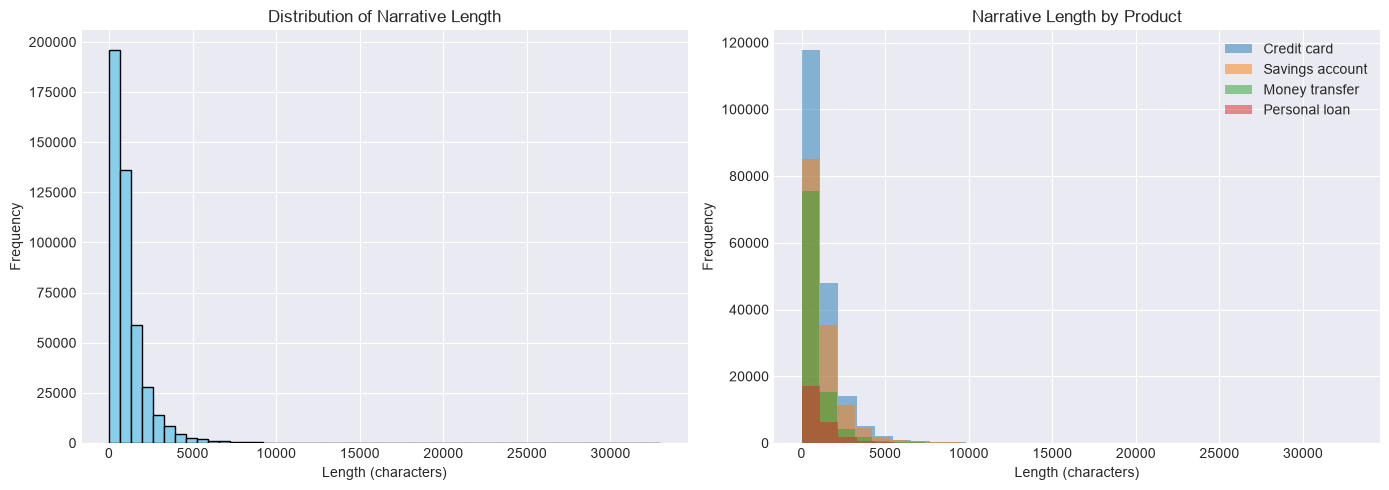

In [11]:
print("=" * 50)
print("NARRATIVE ANALYSIS")
print("=" * 50)

# Count narratives
has_narrative = df_filtered['Consumer complaint narrative'].notna()
print(f"Complaints with narrative: {has_narrative.sum():,}")
print(f"Complaints without narrative: {(~has_narrative).sum():,}")
print(f"Percentage with narrative: {has_narrative.sum()/len(df_filtered)*100:.2f}%")

# Create length column
df_filtered['narrative_length'] = df_filtered['Consumer complaint narrative'].fillna('').str.len()

# Length statistics
print("\nNarrative length statistics:")
print(df_filtered[df_filtered['narrative_length'] > 0]['narrative_length'].describe())

# Plot length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_filtered[df_filtered['narrative_length'] > 0]['narrative_length'], 
             bins=50, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Narrative Length', fontsize=12)
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')

# Box plot by product
for product in df_filtered['Product'].unique():
    product_data = df_filtered[(df_filtered['Product'] == product) & 
                               (df_filtered['narrative_length'] > 0)]
    if len(product_data) > 0:
        axes[1].hist(product_data['narrative_length'], alpha=0.5, label=product, bins=30)

axes[1].set_title('Narrative Length by Product', fontsize=12)
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
print("=" * 50)
print("TEXT CLEANING")
print("=" * 50)

def clean_text(text):
    """
    Clean complaint narrative text
    
    Steps:
    1. Convert to lowercase
    2. Remove boilerplate phrases
    3. Remove special characters
    4. Remove extra whitespace
    """
    if not isinstance(text, str):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove boilerplate phrases
    boilerplate_phrases = [
        r'i am writing to file a complaint',
        r'i am writing to complain about',
        r'this is a complaint about',
        r'i would like to file a complaint',
        r'i want to complain about',
        r'i am submitting this complaint',
        r'this complaint concerns',
        r'i hereby file a complaint',
        r'please accept this as my complaint',
        r'this is to inform you',
        r'i am writing to bring to your attention',
        r'dear [a-z\s]+?,',
    ]
    
    for phrase in boilerplate_phrases:
        text = re.sub(phrase, '', text, flags=re.IGNORECASE)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove special characters but keep periods and spaces
    text = re.sub(r'[^a-zA-Z\s\.]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Test the cleaning
sample = "I am writing to file a complaint about my credit card!!! The billing is incorrect."
print(f"Original: {sample}")
print(f"Cleaned: {clean_text(sample)}")

TEXT CLEANING
Original: I am writing to file a complaint about my credit card!!! The billing is incorrect.
Cleaned: about my credit card the billing is incorrect.


In [13]:
print("=" * 50)
print("APPLYING CLEANING AND SAVING")
print("=" * 50)

# Apply cleaning to narratives
df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(clean_text)

# Remove rows where cleaning resulted in empty text
df_clean = df_filtered[df_filtered['cleaned_narrative'].str.len() > 0].copy()

print(f"Before cleaning: {len(df_filtered):,} rows")
print(f"After cleaning: {len(df_clean):,} rows")
print(f"Removed {len(df_filtered) - len(df_clean):,} rows with empty narratives")

# Add cleaned length column
df_clean['cleaned_length'] = df_clean['cleaned_narrative'].str.len()

# Show before/after
print(f"\nAverage length before cleaning: {df_filtered['narrative_length'].mean():.0f} characters")
print(f"Average length after cleaning: {df_clean['cleaned_length'].mean():.0f} characters")

# Select columns to keep
columns_to_keep = [
    'Product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Date received',
    'cleaned_narrative'
]

df_final = df_clean[columns_to_keep].copy()
df_final.rename(columns={'cleaned_narrative': 'narrative'}, inplace=True)

# Save to CSV
os.makedirs('../data/processed', exist_ok=True)
df_final.to_csv('../data/processed/filtered_complaints.csv', index=False)
print(f"\nCleaned dataset saved to: ../data/processed/filtered_complaints.csv")
print(f"Final shape: {df_final.shape}")

# Quick preview
print("\nSample of cleaned data:")
print(df_final[['Product', 'narrative']].head(3))

APPLYING CLEANING AND SAVING
Before cleaning: 921,808 rows
After cleaning: 454,472 rows
Removed 467,336 rows with empty narratives

Average length before cleaning: 562 characters
Average length after cleaning: 1106 characters

Cleaned dataset saved to: ../data/processed/filtered_complaints.csv
Final shape: (454472, 7)

Sample of cleaned data:
               Product                                          narrative
12237      Credit card  a xxxx xxxx card was opened under my name by a...
12532  Savings account  i made the mistake of using my wellsfargo debi...
13280      Credit card  i have a secured credit card with citibank whi...


In [14]:
print("=" * 50)
print("FINAL SUMMARY STATISTICS")
print("=" * 50)

print(f"Total complaints: {len(df_final):,}")
print(f"Products: {df_final['Product'].nunique()}")
print(f"\nProduct distribution:")
print(df_final['Product'].value_counts())

print(f"\nUnique issues: {df_final['Issue'].nunique()}")
print(f"\nTop 5 issues:")
print(df_final['Issue'].value_counts().head(5))

print(f"\nStates represented: {df_final['State'].nunique()}")
print(f"\nDate range: {df_final['Date received'].min()} to {df_final['Date received'].max()}")

FINAL SUMMARY STATISTICS
Total complaints: 454,472
Products: 4

Product distribution:
Product
Credit card        189334
Savings account    140319
Money transfer      98685
Personal loan       26134
Name: count, dtype: int64

Unique issues: 100

Top 5 issues:
Issue
Managing an account                                75712
Other transaction problem                          49431
Problem with a purchase shown on your statement    40497
Fraud or scam                                      20276
Other features, terms, or problems                 19662
Name: count, dtype: int64

States represented: 62

Date range: 2015-03-19 to 2025-06-15


## Summary
The CFPB complaint dataset containing 9.6 million records was analyzed, focusing on four financial products relevant to CrediTrust: credit cards, personal loans, savings accounts, and money transfers. EDA revealed that credit cards had the highest complaint volume at 47% of filtered complaints, while personal loans represented only 5.1%. Approximately 49.3% of filtered complaints contained consumer narratives, with an average length of 1,140 characters and a maximum of 32,959 characters.

Data preprocessing involved standardizing product names across 21+ variations, filtering to the 4 target products, and applying text cleaning procedures including lowercasing, removal of boilerplate phrases (e.g., "I am writing to file a complaint..."), special character elimination, and URL/email removal. The cleaning process reduced the dataset from 921,808 to 454,472 complaints with meaningful narratives. The final cleaned dataset, containing 454,472 complaints with narratives across 62 states, is balanced across the four product categories and ready for text chunking and embedding in Task 2.